In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Disaster Risk Prediction").getOrCreate()
print(spark.version)

4.0.2


Data Loading

In [2]:
import gdown

file_id = "1SSuF1dJHnjbiMm9H7c2oQ2DpgfTEcm8N"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "world_risk_index.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1SSuF1dJHnjbiMm9H7c2oQ2DpgfTEcm8N
To: /content/world_risk_index.csv
100%|██████████| 148k/148k [00:00<00:00, 52.7MB/s]


'world_risk_index.csv'

In [3]:
df = spark.read.csv("/content/world_risk_index.csv", header=True, inferSchema=True)
df.printSchema()
df.show(5)

root
 |-- Region: string (nullable = true)
 |-- WRI: double (nullable = true)
 |-- Exposure: double (nullable = true)
 |-- Vulnerability: double (nullable = true)
 |-- Susceptibility: double (nullable = true)
 |-- Lack of Coping Capabilities: double (nullable = true)
 |--  Lack of Adaptive Capacities: double (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Exposure Category: string (nullable = true)
 |-- WRI Category: string (nullable = true)
 |-- Vulnerability Category: string (nullable = true)
 |-- Susceptibility Category: string (nullable = true)

+-----------+-----+--------+-------------+--------------+---------------------------+----------------------------+----+-----------------+------------+----------------------+-----------------------+
|     Region|  WRI|Exposure|Vulnerability|Susceptibility|Lack of Coping Capabilities| Lack of Adaptive Capacities|Year|Exposure Category|WRI Category|Vulnerability Category|Susceptibility Category|
+-----------+-----+--------+--------

In [4]:
df = df.withColumnRenamed("Lack of Coping Capabilities", "Lack_Coping")
df = df.withColumnRenamed("Lack of Adaptive Capacities", "Lack_Adaptive")
df = df.withColumnRenamed("WRI Category", "WRI_Category")

In [5]:
print(df.columns)

['Region', 'WRI', 'Exposure', 'Vulnerability', 'Susceptibility', 'Lack_Coping', ' Lack of Adaptive Capacities', 'Year', 'Exposure Category', 'WRI_Category', 'Vulnerability Category', 'Susceptibility Category']


In [6]:
for col_name in df.columns:
    new_name = col_name.strip().replace(" ", "_")
    df = df.withColumnRenamed(col_name, new_name)

print(df.columns)

['Region', 'WRI', 'Exposure', 'Vulnerability', 'Susceptibility', 'Lack_Coping', 'Lack_of_Adaptive_Capacities', 'Year', 'Exposure_Category', 'WRI_Category', 'Vulnerability_Category', 'Susceptibility_Category']


Select Required Columns

In [7]:
features = [
    "Exposure",
    "Susceptibility",
    "Lack_Coping",
    "Lack_of_Adaptive_Capacities"
]

Clean Data

In [8]:
df = df.dropna()
print("Row count:", df.count())
df.groupBy("WRI_Category").count().show()

Row count: 1912
+------------+-----+
|WRI_Category|count|
+------------+-----+
|        High|  378|
|   Very High|  382|
|         Low|  379|
|    Very Low|  390|
|      Medium|  383|
+------------+-----+



ML Pipeline Setup

In [9]:
from pyspark.ml.feature import VectorAssembler, StringIndexer

features = ["Exposure", "Susceptibility", "Lack_Coping", "Lack_of_Adaptive_Capacities"]

assembler = VectorAssembler(inputCols=features, outputCol="features")
indexer = StringIndexer(inputCol="WRI_Category", outputCol="label")

Train-Test Split

In [10]:
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

MODELS

A. Logistic Regression

In [11]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

lr = LogisticRegression(labelCol="label", featuresCol="features")

lr_pipeline = Pipeline(stages=[indexer, assembler, lr])
lr_model = lr_pipeline.fit(train_data)

lr_pred = lr_model.transform(test_data)

B. Decision Tree

In [12]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(labelCol="label", featuresCol="features")

dt_pipeline = Pipeline(stages=[indexer, assembler, dt])
dt_model = dt_pipeline.fit(train_data)

dt_pred = dt_model.transform(test_data)

C. Random Forest

In [13]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=50)

rf_pipeline = Pipeline(stages=[indexer, assembler, rf])
rf_model = rf_pipeline.fit(train_data)

rf_pred = rf_model.transform(test_data)

EVALUATION

In [14]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Logistic Regression
lr_acc = evaluator.setMetricName("accuracy").evaluate(lr_pred)
lr_f1 = evaluator.setMetricName("f1").evaluate(lr_pred)

# Decision Tree
dt_acc = evaluator.setMetricName("accuracy").evaluate(dt_pred)
dt_f1 = evaluator.setMetricName("f1").evaluate(dt_pred)

# Random Forest
rf_acc = evaluator.setMetricName("accuracy").evaluate(rf_pred)
rf_f1 = evaluator.setMetricName("f1").evaluate(rf_pred)

In [15]:
print("===== MODEL COMPARISON =====")

print("Logistic Regression:", lr_acc, lr_f1)
print("Decision Tree:", dt_acc, dt_f1)
print("Random Forest:", rf_acc, rf_f1)

===== MODEL COMPARISON =====
Logistic Regression: 0.9201183431952663 0.9197979168548471
Decision Tree: 0.8106508875739645 0.8059750959926273
Random Forest: 0.9053254437869822 0.9047340544231811


FEATURE IMPORTANCE

In [16]:
rf_model_stage = rf_model.stages[-1]
importances = rf_model_stage.featureImportances

for i, col in enumerate(features):
    print(f"{col}: {importances[i]}")

Exposure: 0.5756968717099632
Susceptibility: 0.18286210945404663
Lack_Coping: 0.18648730208223735
Lack_of_Adaptive_Capacities: 0.05495371675375285


Visualizations

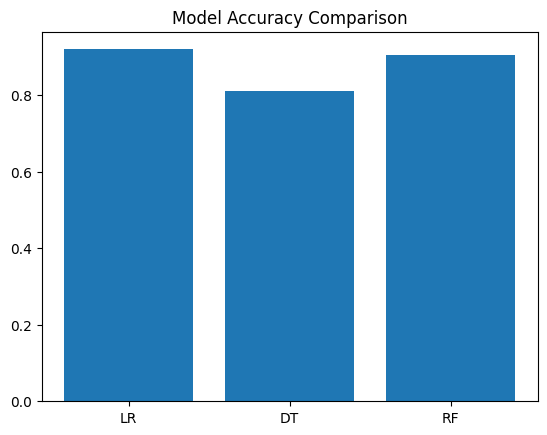

In [17]:
import matplotlib.pyplot as plt

models = ["LR", "DT", "RF"]
accuracy = [0.920, 0.811, 0.905]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.savefig("model_comparison.png")
plt.show()

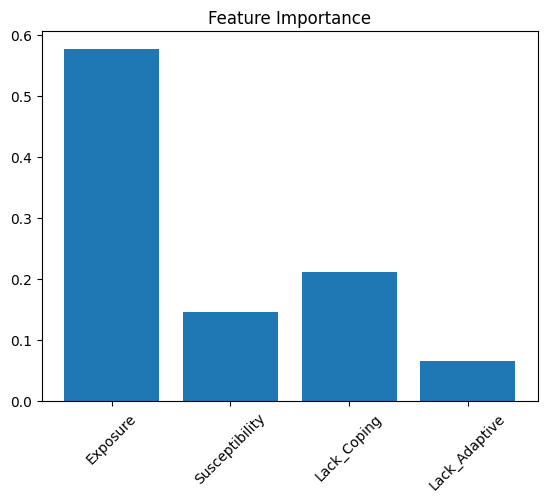

In [18]:
features = ["Exposure", "Susceptibility", "Lack_Coping", "Lack_Adaptive"]
values = [0.577, 0.146, 0.212, 0.065]

plt.figure()
plt.bar(features, values)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.savefig("feature_importance.png")
plt.show()